# Exercice 2 - Entraînez un agent avec une table de décision (Q-table)

## 🎯 Objectif pédagogique

Dans cet exercice, nous allons implémenter notre **premier vrai algorithme d'apprentissage** : le **Q-Learning**.

L'idée est simple : au lieu de choisir des actions au hasard, l'agent va **apprendre** quelle action est la meilleure pour chaque état en construisant une **table de qualité** (Q-table).

```
État: S1   Q-table:   Action Gauche: 0.8   Action Droite: 0.2
                   → L'agent choisit "Gauche" car Q=0.8 est plus grand
```

## 🕹️ Contexte : Pourquoi FrozenLake ?

**FrozenLake-v1** est un environnement avec :
- Un **nombre fini d'états** : 16 cases (4x4)
- Des **trous** : si l'agent tombe, l'épisode est terminé
- Un **but** : atteindre la case but (H) en partant de la case départ (S)

```
S F F F        S = Start (départ)
F H F H        F = Frozen (glace sûre)
F F F H        H = Hole (trou - FAIL)
H F F G        G = Goal (arrivée - WIN)
```

C'est **plus simple que CartPole** car :
- Les états sont **discrets** (on peut compter)
- La Q-table a une taille **connue** (16 états × 4 actions = 64 valeurs)

On ne peut donc pas utiliser CartPole pour le Q-Learning, parce que CartPole a des états **continus** (positions, vitesses). Une Q-table ne fonctionnerait pas bien (trop de combinaisons possibles).

## 1. Import des bibliothèques

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

**Explication :**
- `gymnasium` : pour l'environnement FrozenLake
- `numpy` : pour la Q-table (tableau)
- `random` : pour l'exploration aléatoire

## 2. Partie 1 : Initialisation de l'environnement et de la Q-table

### Création de l'environnement FrozenLake

In [2]:
# Créer l'environnement FrozenLake-v1 (is_slippery=True rend le sol glissant)
env = gym.make("FrozenLake-v1", is_slippery=True)

print(f"Environnement : {env}")
print(f"\nEspace d'observation : {env.observation_space}")
print(f"Nombre d'états : {env.observation_space.n}")
print(f"\nEspace d'action : {env.action_space}")
print(f"Nombre d'actions : {env.action_space.n}")

Environnement : <TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>

Espace d'observation : Discrete(16)
Nombre d'états : 16

Espace d'action : Discrete(4)
Nombre d'actions : 4


**💡 Explication :**

FrozenLake a :
- **16 états** (0 à 15) = 16 cases du plateau 4x4
- **4 actions** : 0=gauche, 1=en bas, 2=droite, 3=en haut

`is_slippery=True` signifie l'agent peut **glisser** : il peut aller dans une direction différente de celle choisie. Cela rend le problème plus réaliste (incertitude).

### Initialisation de la Q-table

In [3]:
# Obtenir les dimensions de la Q-table
n_states = env.observation_space.n    # 16
n_actions = env.action_space.n       # 4

print(f"Dimensions : {n_states} états × {n_actions} actions")

# Créer la Q-table (tableau de zéros)
q_table = np.zeros((n_states, n_actions))

print(f"\nQ-table forme : {q_table.shape}")
print(f"Q-table initiale :\n{q_table}")

Dimensions : 16 états × 4 actions

Q-table forme : (16, 4)
Q-table initiale :
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


**💡 Explication :**

La Q-table est un **tableau 2D** :

| État | Q(gauche) | Q(en bas) | Q(droite) | Q(en haut) |
|------|-----------|-----------|-----------|------------|
| 0    | 0.0       | 0.0       | 0.0       | 0.0        |
| 1    | 0.0       | 0.0       | 0.0       | 0.0        |
| ...  | ...       | ...       | ...       | ...        |
| 15   | 0.0       | 0.0       | 0.0       | 0.0        |

**Q(state, action)** = Au début, toutes les valeurs sont à **0** car l'agent n'a encore rien appris.

### 📝 Synthèse de la Partie 1

**Ce qu'on a appris :**
- ✅ FrozenLake a 16 états discrets et 4 actions
- ✅ La Q-table a la forme (16, 4) = 64 valeurs
- ✅ Au début, toutes les valeurs sont à 0

**Concepts clés :**
- **Q-table** = mémoire de l'agent (état → qualité des actions)
- **Q(state, action)** = "Quelle récompense future attendre si je fais cette action dans cet état ?"

## 3. Partie 2 : Boucle d'entraînement Q-Learning

### La stratégie Epsilon-Greedy

L'agent doit trouver un **équilibre** entre :

- **Explorer** : essayer des actions aléatoires pour découvrir
- **Exploiter** : utiliser ce qu'il a déjà appris

La stratégie **epsilon-greedy** fait exactement cela :

```python
if random.random() < epsilon:
    action = random.choice(actions)  # Explorer
else:
    action = argmax(Q[state])  # Exploiter
```

In [4]:
# Hyperparamètres
learning_rate = 0.8      # Vitesse d'apprentissage (0 à 1)
discount_factor = 0.95   # Importance des récompenses futures (0 à 1)
epsilon = 1.0           # Taux d'exploration initial (1 = 100% aléatoire)
epsilon_decay = 0.0001   # Réduction de epsilon par episode
epsilon_min = 0.01      # Minimum de epsilon

n_episodes = 10000       # Nombre d'épisodes d'entraînement

print("Hyperparamètres :")
print(f"  learning_rate    : {learning_rate}")
print(f"  discount_factor  : {discount_factor}")
print(f"  epsilon initial  : {epsilon}")
print(f"  epsilon_decay    : {epsilon_decay}")
print(f"  epsilon_min      : {epsilon_min}")
print(f"\n→ L'epsilon passera de 1.0 à 0.01 en {int((1.0-epsilon_min)/epsilon_decay)} épisodes")

Hyperparamètres :
  learning_rate    : 0.8
  discount_factor  : 0.95
  epsilon initial  : 1.0
  epsilon_decay    : 0.0001
  epsilon_min      : 0.01

→ L'epsilon passera de 1.0 à 0.01 en 9900 épisodes


**💡 Explication des hyperparamètres :**

| Paramètre | Rôle | Effet |
|-----------|------|-------|
| `learning_rate` (α) | Vitesse d'apprentissage | Plus il est grand, plus l'agent "oublie" le passé |
| `discount_factor` (γ) | Valeur des récompenses futures | Plus il est grand, plus l'agent planifie loin |
| `epsilon` | Taux d'exploration | Plus il est grand, plus l'agent essaie des choses nouvelles |
| `epsilon_decay` | Réduction de l'exploration | L'agent devient plus "confiant" avec le temps |

**Calcul du déclin :**
- epsilon diminue de `epsilon_decay` à chaque épisode
- Avec `epsilon_decay = 0.0001`, il faut `(1.0 - 0.01) / 0.0001 = 9900` épisodes pour atteindre `epsilon_min`

Au début, l'agent doit **beaucoup explorer** (epsilon=1). Plus il apprend, moins il a besoin d'explorer (epsilon diminue jusqu'à 0.01).

### La formule de Bellman (le cœur du Q-Learning)

In [5]:
# C'est la formule que nous allons implémenter :

print("La formule de Bellman :")
print("Q(s, a) = Q(s, a) + alpha * [r + gamma * max(Q(s', a')) - Q(s, a)]")
print()
print("Où :")
print("  s   = état actuel")
print("  a   = action choisie")
print("  r   = récompense immédiate")
print("  s'  = nouvel état")
print("  alpha = learning_rate")
print("  gamma = discount_factor")
print("  max(Q(s', a')) = meilleure valeur Q pour le nouvel état")

La formule de Bellman :
Q(s, a) = Q(s, a) + alpha * [r + gamma * max(Q(s', a')) - Q(s, a)]

Où :
  s   = état actuel
  a   = action choisie
  r   = récompense immédiate
  s'  = nouvel état
  alpha = learning_rate
  gamma = discount_factor
  max(Q(s', a')) = meilleure valeur Q pour le nouvel état


**💡 Interprétation :**

La formule met à jour la valeur Q en tenant compte de :

1. **Ce qu'on savait** : Q(s, a) - la valeur actuelle
2. **Ce qu'on a appris** : r + gamma * max(Q(s', a')) - la "vraie" valeur
3. **La différence** : multipliée par alpha pour éviter de changer trop vite

**Analogie :** C'est comme corriger une erreur de tir au basketball. Plus le lancer était loin de la cible, plus on ajuste.

### Boucle d'entraînement

In [6]:
# Boucle d'entraînement
rewards_per_episode = []

for episode in range(n_episodes):
    # Réinitialiser l'environnement
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        # 1. Stratégie epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()  # Explorer
        else:
            action = np.argmax(q_table[state])  # Exploiter
        
        # 2. Exécuter l'action
        new_state, reward, terminated, truncated, info = env.step(action)
        
        # 3. Mettre à jour la Q-table (FORMULE DE BELLMAN)
        old_value = q_table[state, action]
        next_max = np.max(q_table[new_state])
        new_value = old_value + learning_rate * (reward + discount_factor * next_max - old_value)
        q_table[state, action] = new_value
        
        # 4. Mettre à jour l'état et la récompense
        state = new_state
        total_reward += reward
    
    # 5. Réduire epsilon (explorer de moins en moins)
    epsilon = max(epsilon_min, epsilon - epsilon_decay)
    rewards_per_episode.append(total_reward)
    
    # Afficher la progression tous les 1000 épisodes
    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode+1}/{n_episodes} - Epsilon: {epsilon:.3f} - Reward moyen: {np.mean(rewards_per_episode[-1000:]):.3f}")

Episode 1000/10000 - Epsilon: 0.900 - Reward moyen: 0.012
Episode 2000/10000 - Epsilon: 0.800 - Reward moyen: 0.019
Episode 3000/10000 - Epsilon: 0.700 - Reward moyen: 0.019
Episode 4000/10000 - Epsilon: 0.600 - Reward moyen: 0.024
Episode 5000/10000 - Epsilon: 0.500 - Reward moyen: 0.032
Episode 6000/10000 - Epsilon: 0.400 - Reward moyen: 0.041
Episode 7000/10000 - Epsilon: 0.300 - Reward moyen: 0.055
Episode 8000/10000 - Epsilon: 0.200 - Reward moyen: 0.081
Episode 9000/10000 - Epsilon: 0.100 - Reward moyen: 0.136
Episode 10000/10000 - Epsilon: 0.010 - Reward moyen: 0.283


In [7]:
# Fermer l'environnement
env.close()

print(f"\nEntraînement terminé !")
print(f"Épisodes totaux : {n_episodes}")
print(f"Épisodes avec succès (reward=1) : {sum(rewards_per_episode)}")
print(f"Taux de réussite final (100 derniers) : {np.mean(rewards_per_episode[-100:])*100:.1f}%")


Entraînement terminé !
Épisodes totaux : 10000
Épisodes avec succès (reward=1) : 702
Taux de réussite final (100 derniers) : 42.0%


**💡 Explication de la boucle :**

À chaque step :
1. **Choisir** une action (explore ou exploite selon epsilon)
2. **Exécuter** l'action, obtenir reward et new_state
3. **Mettre à jour** la Q-table avec la formule de Bellman
4. **Répéter** jusqu'à la fin de l'épisode

Plus l'agent apprend, plus il peut **exploiter** ses connaissances. Diminuer epsilon réduit l'exploration aléatoire au profit de l'exploitation.

### 📝 Synthèse de la Partie 2

**Ce qu'on a appris :**
- ✅ La stratégie epsilon-greedy (explore vs exploite)
- ✅ La formule de Bellman pour mettre à jour la Q-table
- ✅ Le déclin de epsilon pour tendre vers l'exploitation

**Concepts clés :**
- **Exploration** = essayer des actions aléatoires pour découvrir
- **Exploitation** = utiliser les connaissances acquises
- **Epsilon-greedy** = compromis entre exploration et exploitation

## 4. Partie 3 : Évaluation de l'agent

### Tester l'agent entraîné

In [8]:
# Recréer l'environnement pour l'évaluation
env = gym.make("FrozenLake-v1", is_slippery=True)

# Paramètres d'évaluation : epsilon=0 (pas d'exploration)
n_eval_episodes = 100
total_wins = 0
rewards_eval = []

for episode in range(n_eval_episodes):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        # TOUJOURS exploiter (pas d'exploration)
        action = np.argmax(q_table[state])
        
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
    
    total_wins += reward  # reward = 1 si succès, 0 sinon
    rewards_eval.append(total_reward)

env.close()

print(f"=== Résultats de l'évaluation ===")
print(f"Épisodes évalués : {n_eval_episodes}")
print(f"Victoires : {total_wins}")
print(f"Taux de réussite : {total_wins/n_eval_episodes*100:.1f}%")

=== Résultats de l'évaluation ===
Épisodes évalués : 100
Victoires : 77
Taux de réussite : 77.0%


**💡 Différence entraînement vs évaluation :**

| Phase | Epsilon | Objectif |
|-------|---------|----------|
| Entraînement | Décroissant (1 → 0.01) | Apprendre |
| Évaluation | 0 | Mesurer la performance |

Pendant l'évaluation, l'agent **exploite seulement** ses connaissances (pas d'exploration aléatoire).

### Visualisation des performances

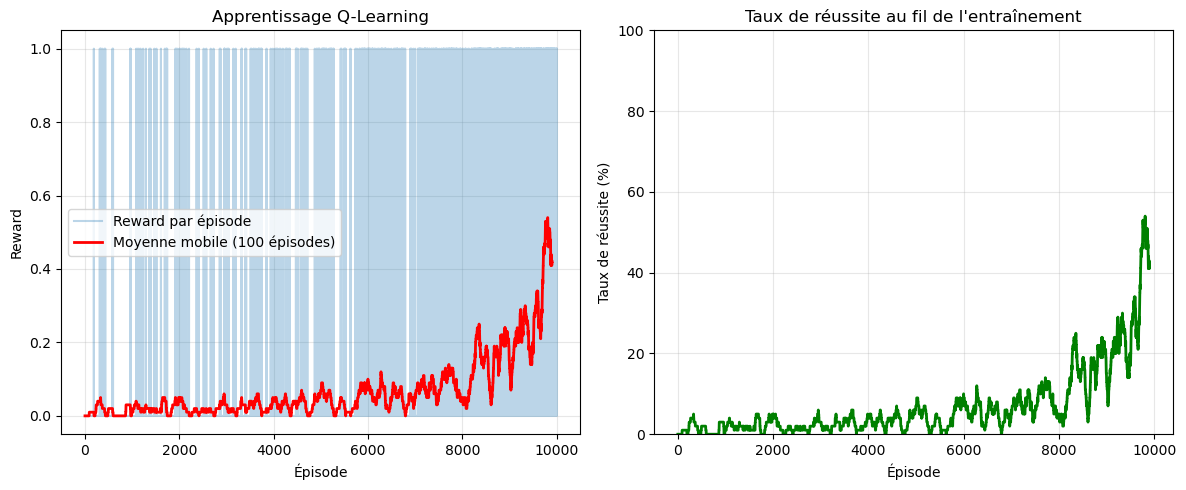

In [9]:
# Calculer la moyenne mobile (lisse les variations)
window = 100
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))

# Graphe 1 : Apprentissage
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode, alpha=0.3, label='Reward par épisode')
plt.plot(moving_avg, color='red', linewidth=2, label=f'Moyenne mobile ({window} épisodes)')
plt.xlabel('Épisode')
plt.ylabel('Reward')
plt.title('Apprentissage Q-Learning')
plt.legend()
plt.grid(alpha=0.3)

# Graphe 2 : Taux de réussite
plt.subplot(1, 2, 2)
success_rate = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid') * 100
plt.plot(success_rate, color='green', linewidth=2)
plt.xlabel('Épisode')
plt.ylabel('Taux de réussite (%)')
plt.title('Taux de réussite au fil de l\'entraînement')
plt.grid(alpha=0.3)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

**💡 Lecture des graphiques :**

**Gauche :** La courbe rouge montre que l'agent **améliore** ses performances au fil des épisodes.

**Droite :** Le taux de réussite augmente et se **stabilise** (ou oscille si l'environnement est stochastique).

**⚠️ Important - Pourquoi les deux courbes sont identiques ?**

Dans FrozenLake, c'est **normal** car :
- `reward = 1` uniquement si l'agent atteint le but (victoire)
- `reward = 0` sinon (échec)

Donc : `reward_total = nombre_de_victoires / episodes_total = taux_de_réussite`

**Attention :** Ce n'est pas toujours le cas !
- Pour **CartPole/LunarLander** : reward = nombre de steps survécus (0 à 500)
- Le reward et le taux de réussite sont alors **différents**

### Observer la Q-table apprise

In [10]:
print("=== Q-table finale (aperçu) ===")
print(f"\n{'État':<8} {'←':<8} {'↓':<8} {'→':<8} {'↑':<8} {'Meilleure'}")
print("-" * 48)
actions = ['←', '↓', '→', '↑']

for state in range(n_states):
    values = q_table[state]
    best_action = actions[np.argmax(values)]
    print(f"{state:<8} {values[0]:<8.2f} {values[1]:<8.2f} {values[2]:<8.2f} {values[3]:<8.2f} {best_action}")

=== Q-table finale (aperçu) ===

État     ←        ↓        →        ↑        Meilleure
------------------------------------------------
0        0.16     0.05     0.04     0.05     ←
1        0.01     0.02     0.03     0.16     ↑
2        0.01     0.01     0.01     0.11     ↑
3        0.00     0.00     0.01     0.03     ↑
4        0.23     0.02     0.05     0.01     ←
5        0.00     0.00     0.00     0.00     ←
6        0.00     0.00     0.11     0.00     →
7        0.00     0.00     0.00     0.00     ←
8        0.00     0.01     0.01     0.32     ↑
9        0.04     0.53     0.00     0.01     ↓
10       0.81     0.01     0.02     0.00     ←
11       0.00     0.00     0.00     0.00     ←
12       0.00     0.00     0.00     0.00     ←
13       0.00     0.02     0.48     0.10     →
14       0.27     0.98     0.21     0.29     ↓
15       0.00     0.00     0.00     0.00     ←


**💡 Interprétation :**

La Q-table montre la **valeur apprise** de chaque action dans chaque état :
- Les **trous** (États 5, 7, 11, 12, 15) ont des valeurs faibles ou nulles
- Les états **proches du but** ont des valeurs positives
- La colonne "Meilleure" indique la direction optimale pour chaque état

---

## 🎬 Enregistrement vidéo

L'agent **Q-Learning** utilise la politique apprise. Observez comment il évite les trous !


In [13]:
import os
import imageio
from IPython.display import Video
import numpy as np

frames_dir = "./videos/frames"
video_folder = "./videos"
os.makedirs(frames_dir, exist_ok=True)
os.makedirs(video_folder, exist_ok=True)

os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"

env = gym.make("FrozenLake-v1", render_mode="rgb_array")

print("Enregistrement de 3 episode(s) avec agent Q-Learning...", flush=True)

frames = []

for episode in range(3):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        frame = env.render()
        if frame is not None:
            frames.append(frame)
    
    result = "Succes!" if total_reward > 0 else "Echec"
    print(f"Episode {episode+1}: {result} (reward={total_reward:.1f})")

env.close()

video_path = f"{video_folder}/exercice_02_frozenlake_qlearning.mp4"
imageio.mimwrite(video_path, frames, fps=30)

print(f"Video enregistree: {video_path}")
Video(video_path, embed=True, width=640)

Enregistrement de 3 episode(s) avec agent Q-Learning...
Episode 1: Succes! (reward=1.0)
Episode 2: Succes! (reward=1.0)
Episode 3: Succes! (reward=1.0)
Video enregistree: ./videos/exercice_02_frozenlake_qlearning.mp4


## 5. Conclusion

### Ce qu'on a accompli

| Compétence | Status |
|-----------|--------|
| Comprendre le Q-Learning | ✅ |
| Implémenter une Q-table | ✅ |
| Utiliser la stratégie epsilon-greedy | ✅ |
| Appliquer la formule de Bellman | ✅ |
| Évaluer un agent RL | ✅ |

### Observations clés

- Le **Q-Learning** permet d'apprendre sans connaître la politique optimale
- La **Q-table** est une approximation de la fonction de valeur-action
- L'agent apprend par **essai-erreur** en explorant l'environnement

### Limitations du Q-Learning

- Ne fonctionne bien que pour les espaces **discrets**
- La Q-table peut devenir **très grande** pour des problèmes complexes

### Prochaines étapes

- **Exercice 3 :** Remplacer la Q-table par un **réseau de neurones** (DQN)
- **Mission :** Appliquer au LunarLander (score > 200)